# House Price Prediction Project

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
df=pd.read_csv('data.csv')

## data exploration 

In [3]:
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


In [4]:
df.describe().round()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0
mean,551963.0,3.0,2.0,2139.0,14853.0,2.0,0.0,0.0,3.0,1827.0,312.0,1971.0,809.0
std,563835.0,1.0,1.0,963.0,35884.0,1.0,0.0,1.0,1.0,862.0,464.0,30.0,979.0
min,0.0,0.0,0.0,370.0,638.0,1.0,0.0,0.0,1.0,370.0,0.0,1900.0,0.0
25%,322875.0,3.0,2.0,1460.0,5001.0,1.0,0.0,0.0,3.0,1190.0,0.0,1951.0,0.0
50%,460943.0,3.0,2.0,1980.0,7683.0,2.0,0.0,0.0,3.0,1590.0,0.0,1976.0,0.0
75%,654962.0,4.0,2.0,2620.0,11001.0,2.0,0.0,0.0,4.0,2300.0,610.0,1997.0,1999.0
max,26590000.0,9.0,8.0,13540.0,1074218.0,4.0,1.0,4.0,5.0,9410.0,4820.0,2014.0,2014.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

In [6]:
df.dtypes

date                 str
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street               str
city                 str
statezip             str
country              str
dtype: object

In [7]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

## Exploratory Data Analysis

In [8]:
df['date']=pd.to_datetime(df['date'])

In [9]:
df['year']=df['date'].dt.year

In [10]:
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country,year
0,2014-05-02,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA,2014
1,2014-05-02,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA,2014
2,2014-05-02,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA,2014
3,2014-05-02,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA,2014
4,2014-05-02,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA,2014
4596,2014-07-09,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA,2014
4597,2014-07-09,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA,2014
4598,2014-07-10,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA,2014


In [11]:
df=df.drop('date',axis=1)

In [12]:
df=df.drop('street',axis=1)

In [13]:
df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip,country,year
0,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,WA 98133,USA,2014
1,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,WA 98119,USA,2014
2,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,WA 98042,USA,2014
3,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,WA 98008,USA,2014
4,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,WA 98052,USA,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,Seattle,WA 98133,USA,2014
4596,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,Bellevue,WA 98007,USA,2014
4597,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,Renton,WA 98059,USA,2014
4598,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,Seattle,WA 98178,USA,2014


In [14]:
df['price']=df['price'].round()

In [15]:
df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip,country,year
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,WA 98133,USA,2014
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,WA 98119,USA,2014
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,WA 98042,USA,2014
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,WA 98008,USA,2014
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,WA 98052,USA,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,308167.0,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,Seattle,WA 98133,USA,2014
4596,534333.0,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,Bellevue,WA 98007,USA,2014
4597,416904.0,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,Renton,WA 98059,USA,2014
4598,203400.0,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,Seattle,WA 98178,USA,2014


In [16]:
df.drop(columns=['statezip'],inplace=True)

In [17]:
df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,country,year
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,USA,2014
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,USA,2014
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,USA,2014
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,USA,2014
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,USA,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,308167.0,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,Seattle,USA,2014
4596,534333.0,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,Bellevue,USA,2014
4597,416904.0,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,Renton,USA,2014
4598,203400.0,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,Seattle,USA,2014


In [18]:
print(df.nunique())

price            1741
bedrooms           10
bathrooms          26
sqft_living       566
sqft_lot         3113
floors              6
waterfront          2
view                5
condition           5
sqft_above        511
sqft_basement     207
yr_built          115
yr_renovated       60
city               44
country             1
year                1
dtype: int64


In [19]:
df['country'].groupby(df['country']).count()

country
USA    4600
Name: country, dtype: int64

In [20]:
df['year'].groupby(df['year']).count()

year
2014    4600
Name: year, dtype: int64

In [21]:
df.drop(columns=['country','year'],inplace=True)

In [22]:
df.head(5)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond


In [23]:
df.sort_values(by='price',ascending=True).head(10)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city
4567,0.0,4.0,2.50,4080,18362,2.0,0,2,4,4080,0,1983,0,Clyde Hill
4588,0.0,4.0,2.25,2890,18226,3.0,1,4,3,2890,0,1984,0,Renton
4542,0.0,5.0,3.50,2640,6895,2.0,0,0,3,2640,0,2001,0,Snoqualmie
4374,0.0,2.0,2.50,2200,188200,1.0,0,3,3,2200,0,2007,0,Enumclaw
4358,0.0,5.0,3.50,3480,36615,2.0,0,0,4,2490,990,1983,0,Issaquah
4357,0.0,6.0,2.75,3200,9200,1.0,0,2,4,1600,1600,1953,1983,Burien
4356,0.0,4.0,2.75,2600,5390,1.0,0,0,4,1300,1300,1960,2001,Seattle
4354,0.0,3.0,1.75,1490,10125,1.0,0,0,4,1490,0,1962,0,Federal Way
4394,0.0,5.0,3.25,3690,12353,2.0,0,0,5,3690,0,1977,0,Lake Forest Park
4405,0.0,4.0,3.75,3300,4545,1.5,0,4,3,2600,700,1926,1999,Seattle


In [24]:
df=df[df['price']>0]

In [25]:
df.sort_values(by='price',ascending=True).head(10)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city
4351,7800.0,2.0,1.00,780,16344,1.0,0,0,1,780,0,1942,0,Tukwila
1219,80000.0,1.0,0.75,430,5050,1.0,0,0,2,430,0,1912,0,Carnation
1587,83000.0,2.0,1.00,900,8580,1.0,0,0,3,900,0,1918,0,Tukwila
4407,83300.0,3.0,2.00,1490,7770,1.0,0,0,4,1490,0,1990,0,Covington
4415,83300.0,3.0,2.00,1370,78408,1.0,0,0,5,1370,0,1964,0,Covington
4345,84350.0,4.0,2.00,2630,16475,2.0,0,0,4,2630,0,1953,1983,Yarrow Point
4425,87500.0,2.0,1.00,780,6685,1.0,0,0,4,780,0,1948,0,Auburn
588,90000.0,2.0,1.00,790,2640,1.0,0,0,3,790,0,1973,2013,Kirkland
1283,90000.0,2.0,1.00,580,7500,1.0,0,0,3,580,0,1943,2002,Seattle
290,100000.0,2.0,1.00,910,22000,1.0,0,0,3,910,0,1956,2001,Algona


In [26]:
df[df['price']<0].count()

price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
city             0
dtype: int64

In [27]:
df.sort_values(by='sqft_living').head(10)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city
3778,276000.0,1.0,0.75,370,1801,1.0,0,0,5,370,0,1923,0,Seattle
2919,245000.0,1.0,0.75,380,15000,1.0,0,0,3,380,0,1963,2008,Burien
2416,280000.0,1.0,0.75,420,6720,1.0,0,0,3,420,0,1922,2008,Seattle
1219,80000.0,1.0,0.75,430,5050,1.0,0,0,2,430,0,1912,0,Carnation
4184,150000.0,3.0,0.75,490,38500,1.5,0,0,4,490,0,1959,0,Skykomish
4368,160000.0,2.0,1.00,520,22334,1.0,0,0,2,520,0,1951,0,SeaTac
1216,353000.0,1.0,1.00,550,1279,2.0,0,0,3,550,0,2008,0,Seattle
1833,299000.0,1.0,0.75,560,12120,1.0,0,0,3,560,0,1967,2011,Carnation
1283,90000.0,2.0,1.00,580,7500,1.0,0,0,3,580,0,1943,2002,Seattle
4338,202000.0,1.0,1.00,590,833,1.0,0,0,4,590,0,1926,1993,Seattle


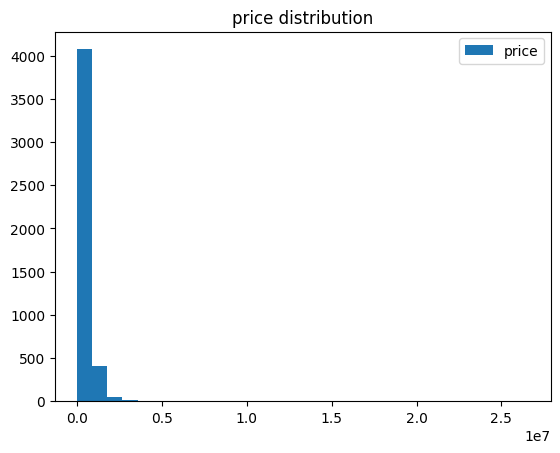

In [28]:
plt.hist(df['price'],bins=30,label='price')
plt.legend()
plt.title('price distribution')
plt.show()

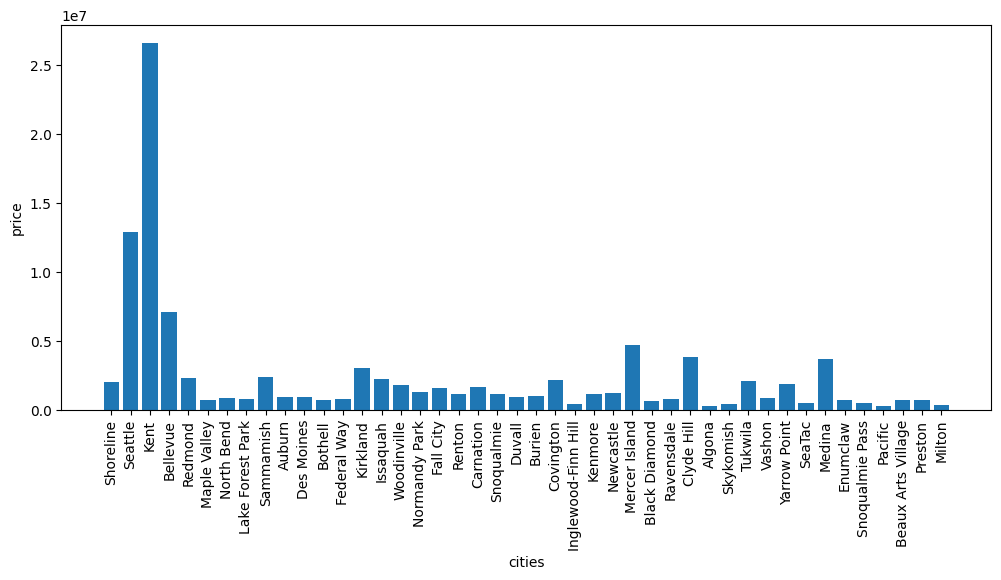

In [29]:
plt.figure(figsize=(12,5))
plt.bar(df['city'],df['price'])
plt.xlabel('cities')
plt.ylabel('price')
plt.xticks(rotation=90)
plt.show()

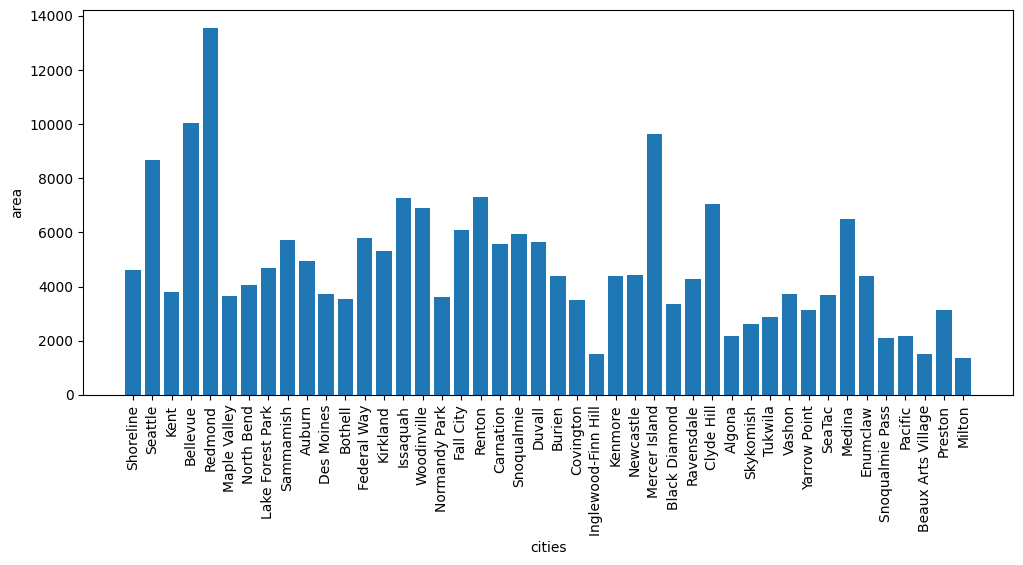

In [30]:
plt.figure(figsize=(12,5))
plt.bar(df['city'],df['sqft_living'])
plt.xlabel('cities')
plt.ylabel('area')
plt.xticks(rotation=90)
plt.show()

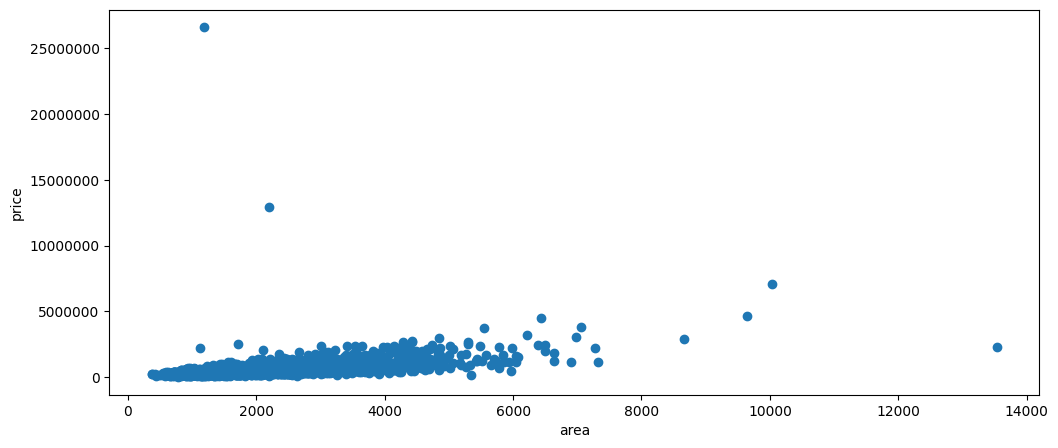

In [31]:
plt.figure(figsize=(12,5))
plt.scatter(df['sqft_living'],df['price'])
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('area')
plt.ylabel('price')
plt.show()

Observation:
A positive relationship exists between living area and house price, but several extreme outliers are visible.

## Encoding Categorical Variables


In [32]:
new_df=pd.get_dummies(df,columns=['city'],dtype=int)

In [33]:
new_df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,city_SeaTac,city_Seattle,city_Shoreline,city_Skykomish,city_Snoqualmie,city_Snoqualmie Pass,city_Tukwila,city_Vashon,city_Woodinville,city_Yarrow Point
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,...,0,0,1,0,0,0,0,0,0,0
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,...,0,1,0,0,0,0,0,0,0,0
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,...,0,0,0,0,0,0,0,0,0,0
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,...,0,0,0,0,0,0,0,0,0,0
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,308167.0,3.0,1.75,1510,6360,1.0,0,0,4,1510,...,0,1,0,0,0,0,0,0,0,0
4596,534333.0,3.0,2.50,1460,7573,2.0,0,0,3,1460,...,0,0,0,0,0,0,0,0,0,0
4597,416904.0,3.0,2.50,3010,7014,2.0,0,0,3,3010,...,0,0,0,0,0,0,0,0,0,0
4598,203400.0,4.0,2.00,2090,6630,1.0,0,0,3,1070,...,0,1,0,0,0,0,0,0,0,0


In [34]:
new_df.drop(columns='sqft_lot',inplace=True)

## Outlier Handling

<Axes: ylabel='price'>

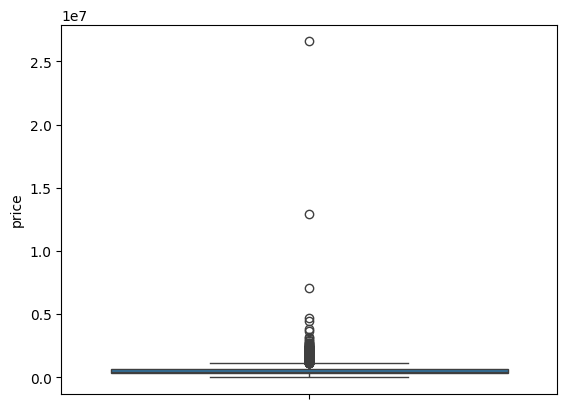

In [35]:
sns.boxplot(new_df['price'])

observation: it can be seen that price column have outliers

In [36]:
#handling outliers in price column
q1=new_df['price'].quantile(0.25)
q3=new_df['price'].quantile(0.75)
iqr=q3-q1
lower=q1-iqr*1.5
upper=q3+iqr*1.5

new_df=new_df[
    (new_df['price']>=lower)&
    (new_df['price']<=upper)]

<Axes: ylabel='sqft_living'>

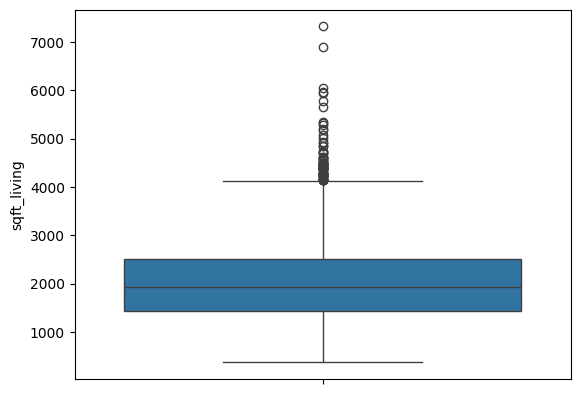

In [37]:
sns.boxplot(new_df['sqft_living'])

observation: it can be seen that sqaure feet column has outliers

In [38]:
#handling outliers in sqft_living column
q1=new_df['sqft_living'].quantile(0.25)
q3=new_df['sqft_living'].quantile(0.75)
iqr=q3-q1
lower=q1-iqr*1.5
upper=q3+iqr*1.5
new_df=new_df[
    (new_df['sqft_living']>=lower)&
    (new_df['sqft_living']<=upper)]

<Axes: ylabel='price'>

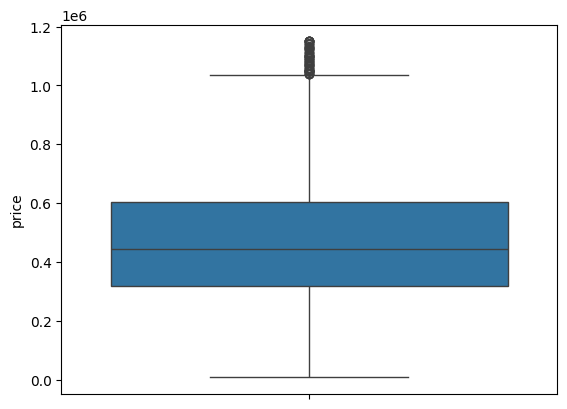

In [39]:
sns.boxplot(new_df['price'])

<Axes: ylabel='sqft_living'>

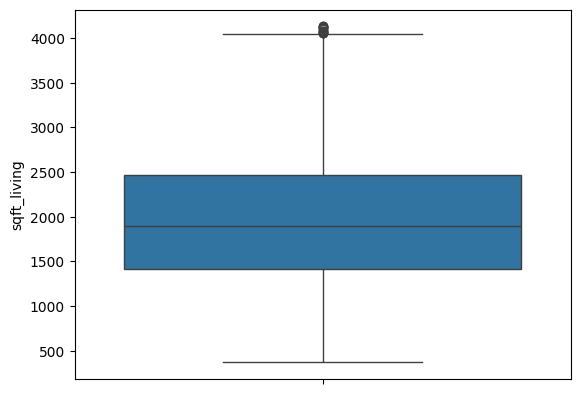

In [40]:
sns.boxplot(new_df['sqft_living'])

observation:
after handling outliers 

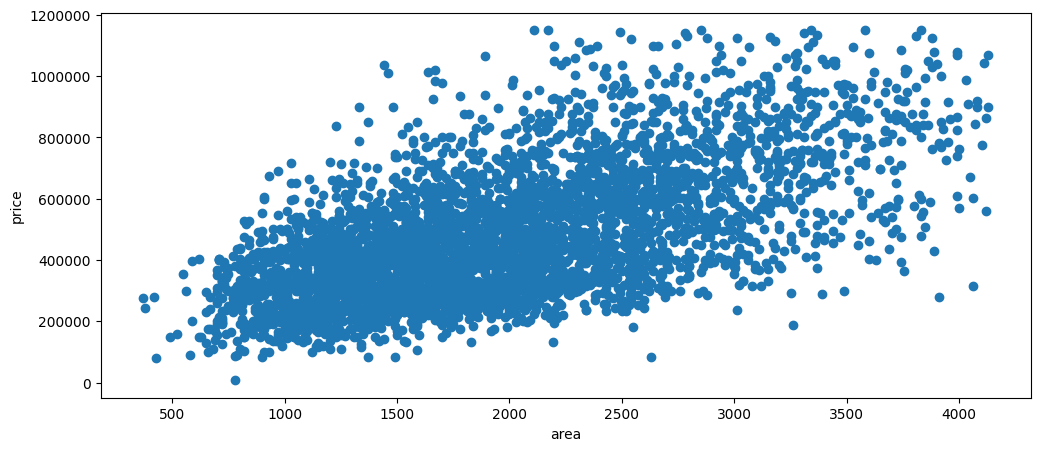

In [41]:
plt.figure(figsize=(12,5))
plt.scatter(new_df['sqft_living'],new_df['price'])
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('area')
plt.ylabel('price')
plt.show()

Observation:
After removing outliers, the relationship between sqft_living and price appears more consistent and linear.

<Axes: >

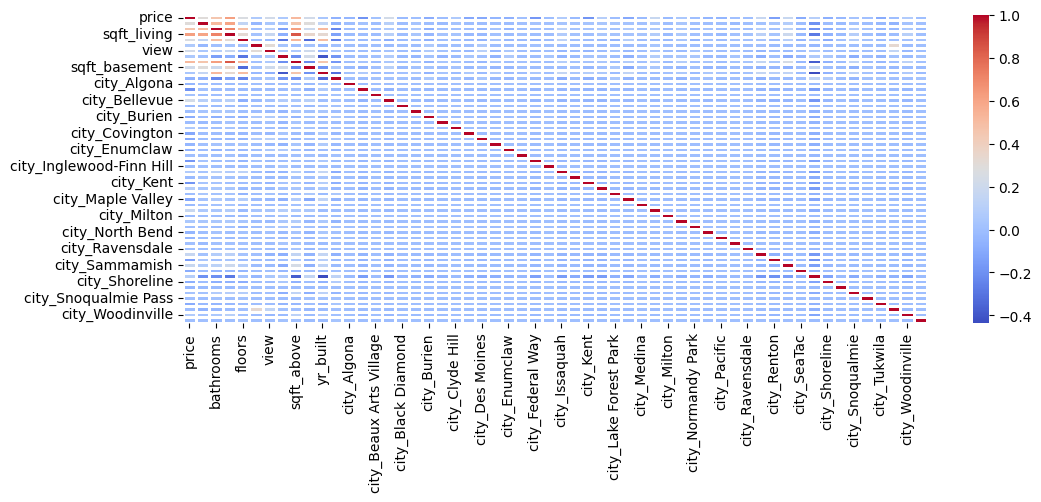

In [42]:
plt.figure(figsize=(12,4))
sns.heatmap(new_df.corr(),cmap='coolwarm',linewidth=1)

## Feature Engineering

In [43]:
new_df['house_age']=2014-new_df['yr_built']

In [44]:
new_df['total_rooms']=new_df['bedrooms']+new_df['bathrooms']

In [45]:
def status(x):
    if x==0:
        return 1
    else:
        return 0
new_df['renovated_status']=new_df['yr_renovated'].apply(status)

In [46]:
new_df['price']=np.log1p(new_df['price'])

## Model building

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

In [48]:
Y=new_df['price']
X= new_df.drop(['price','yr_built'], axis=1)

In [49]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [50]:
num_cols=['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'waterfront','view', 'condition', 'sqft_above', 'sqft_basement','yr_renovated']

X_train_scaled = x_train.copy()
X_test_scaled = x_test.copy()
scaler = StandardScaler()
# Scale training data
X_train_scaled[num_cols] = scaler.fit_transform(x_train[num_cols])
# Scale testing data
X_test_scaled[num_cols] = scaler.transform(x_test[num_cols])
# Convert back to DataFrame (optional but useful)
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=x_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=x_test.columns
)


In [51]:
model=LinearRegression()

In [52]:
model.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [53]:
y_pred=model.predict(X_test_scaled)

### Model evaluation

In [54]:
print(f'mae is :{mean_absolute_error(y_test,y_pred)}')
print(f'r2 score is: {r2_score(y_test,y_pred)}')
print(f'mse score is :{mean_squared_error(y_test,y_pred)}')

mae is :0.17867066995660366
r2 score is: 0.718056908946378
mse score is :0.05828946565801391


In [55]:
print("Train Score:", model.score(X_train_scaled, y_train))
print("Test Score:", model.score(X_test_scaled, y_test))

Train Score: 0.6981917065693417
Test Score: 0.718056908946378


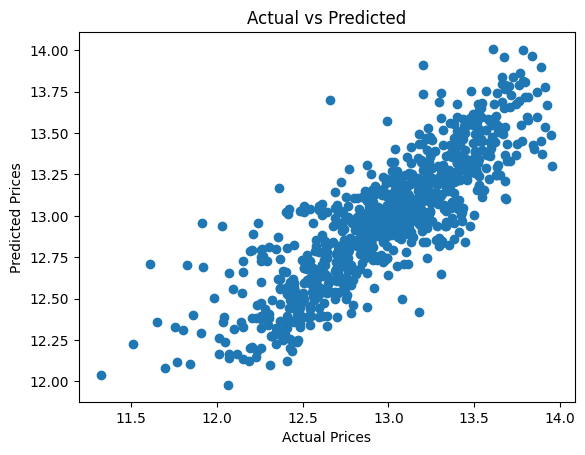

In [56]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

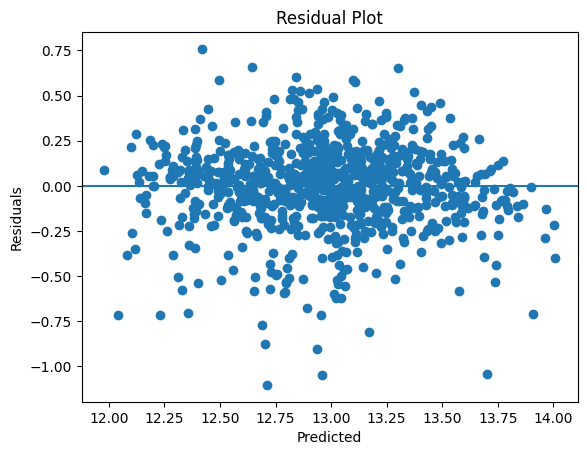

In [57]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

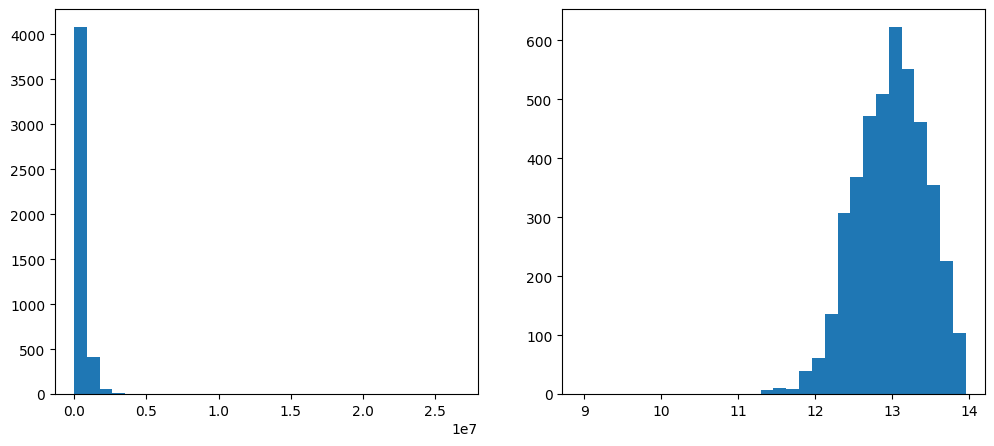

In [58]:
fig,ax=plt.subplots(1,2,figsize=(12,5))
ax[0].hist(df['price'], bins=30)
ax[1].hist(new_df['price'], bins=30)
plt.show()

In [59]:
from sklearn.ensemble import RandomForestRegressor


In [60]:
rf_model= RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    random_state=42
)

In [61]:
rf_model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [62]:
y_pred=rf_model.predict(x_test)

In [63]:
rf_r2_score=r2_score(y_test,y_pred)

In [64]:
print(rf_r2_score)

0.7060671543993264


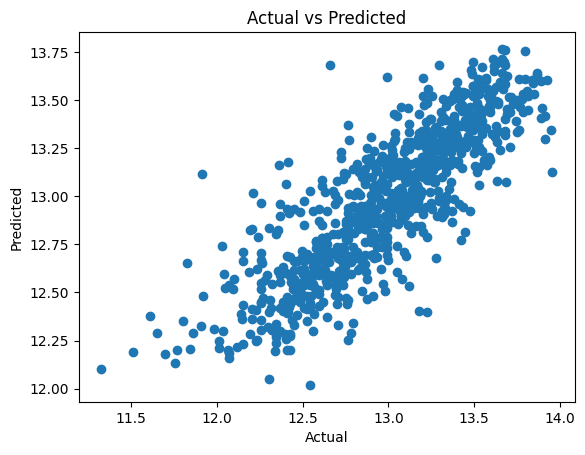

In [65]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

In [66]:
print("Train Score:", rf_model.score(x_train, y_train))
print("Test Score:", rf_model.score(x_test, y_test))

Train Score: 0.9059142371279354
Test Score: 0.7060671543993264


In [67]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_model,
    X,
    Y,
    cv=5
)

print(scores)
print(scores.mean())

[0.71073402 0.65751402 0.71657658 0.71085237 0.58747933]
0.6766312638948164


In [68]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

          Feature  Importance
2     sqft_living    0.429238
45   city_Seattle    0.072485
54      house_age    0.064729
7      sqft_above    0.051787
13  city_Bellevue    0.035201
1       bathrooms    0.024281
41   city_Redmond    0.023160
6       condition    0.023031
55    total_rooms    0.022711
11    city_Auburn    0.019285


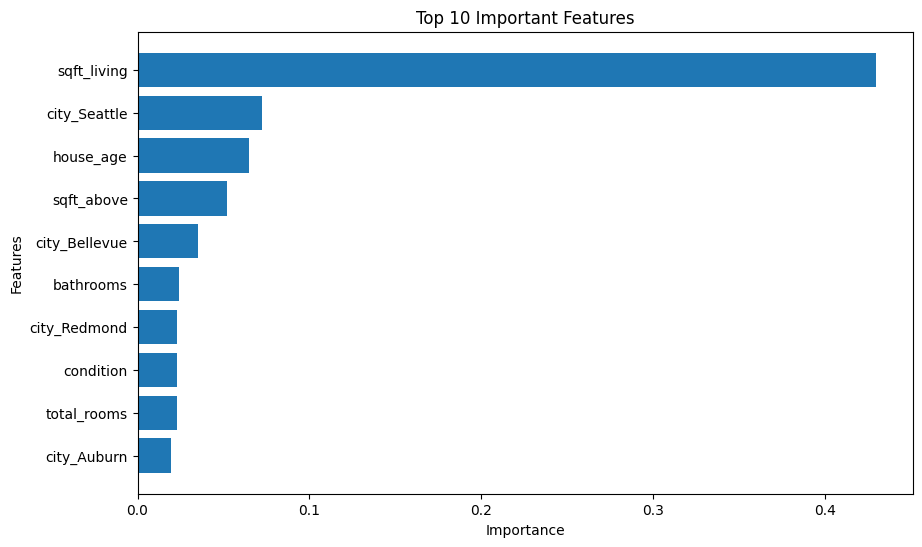

In [69]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

## Conclusion

This project successfully predicts house prices using machine learning techniques. Data preprocessing, outlier handling, feature engineering, and feature scaling improved model performance significantly. Linear Regression achieved an R² score of approximately 0.71, demonstrating good predictive capability.